In [1]:
!pip install thop -q

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets, transforms, models
from thop import profile, clever_format

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import time
import json
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [5]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f" PyTorch version: {torch.__version__}")
print(f" CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")
    print(f" GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


 PyTorch version: 2.8.0+cu126
 CUDA available: True
 GPU: Tesla T4
 GPU Memory: 15.83 GB


In [38]:
class Config:
    IMG_SIZE = 224
    BATCH_SIZE = 64
    NUM_CLASSES = 10
    TRAIN_SPLIT = 0.8
    VAL_SPLIT = 0.1
    TEST_SPLIT = 0.1
    
    MEAN = [0.485, 0.456, 0.406]
    STD = [0.229, 0.224, 0.225]
    
    WARMUP_EPOCHS = 5
    WARMUP_LR = 1e-3
    FINETUNE_LR = 1e-5
    PATIENCE = 5
    
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    DATA_DIR = '/kaggle/input/eurosat-dataset/EuroSAT'
    OUTPUT_DIR = '/kaggle/working'

config = Config()
print(f"Device: {config.DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [39]:
train_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.MEAN, std=config.STD)
])

test_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.MEAN, std=config.STD)
])

In [40]:
full_dataset = datasets.ImageFolder(root=config.DATA_DIR)

total_size = len(full_dataset)
train_size = int(config.TRAIN_SPLIT * total_size)
val_size = int(config.VAL_SPLIT * total_size)
test_size = total_size - train_size - val_size

In [41]:
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [42]:
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform


In [43]:
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2)

print(f" Data splits: Train={train_size}, Val={val_size}, Test={test_size}")
print(f" Classes: {full_dataset.classes}")


 Data splits: Train=21600, Val=2700, Test=2700
 Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [44]:
def build_vgg16(num_classes=10, pretrained=True):
    model = models.vgg16(pretrained=pretrained)
    model.classifier[6] = nn.Linear(4096, num_classes)
    return model

def build_mobilenetv2(num_classes=10, pretrained=True):
    model = models.mobilenet_v2(pretrained=pretrained)
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)
    return model

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def calculate_flops(model, input_size=(1, 3, 224, 224)):
    dummy_input = torch.randn(input_size).to(config.DEVICE)
    flops, params = profile(model, inputs=(dummy_input,), verbose=False)
    flops_str, params_str = clever_format([flops, params], "%.3f")
    return flops, flops_str, params_str


In [45]:
vgg16 = build_vgg16().to(config.DEVICE)
mobilenet = build_mobilenetv2().to(config.DEVICE)

In [46]:
results = {}
for name, model in [("VGG16", vgg16), ("MobileNetV2", mobilenet)]:
    total_params, trainable_params = count_parameters(model)
    flops, flops_str, params_str = calculate_flops(model)
    
    results[name] = {
        'total_params': total_params,
        'trainable_params': trainable_params,
        'flops': flops,
        'flops_str': flops_str,
        'params_str': params_str,
        'size_mb': total_params * 4 / (1024**2)  # Assuming float32
    }
    
    print(f"\n{name}:")
    print(f"  Parameters: {params_str} ({total_params:,})")
    print(f"  FLOPs: {flops_str} ({flops:,.0f})")
    print(f"  Model Size: {results[name]['size_mb']:.2f} MB")


VGG16:
  Parameters: 134.302M (134,301,514)
  FLOPs: 15.466G (15,466,259,456)
  Model Size: 512.32 MB

MobileNetV2:
  Parameters: 2.237M (2,236,682)
  FLOPs: 326.220M (326,219,520)
  Model Size: 8.53 MB


In [47]:
ratio = results['VGG16']['flops'] / results['MobileNetV2']['flops']
print(f"\n VGG16 is {ratio:.1f}x more computationally expensive than MobileNetV2")


 VGG16 is 47.4x more computationally expensive than MobileNetV2


In [48]:
with open(f'{config.OUTPUT_DIR}/resource_audit.json', 'w') as f:
    json.dump({k: {**v, 'flops': float(v['flops'])} for k, v in results.items()}, f, indent=2)

In [49]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{running_loss/len(loader):.4f}', 
                         'acc': f'{100.*correct/total:.2f}%'})
    
    return running_loss / len(loader), 100. * correct / total


In [50]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Validation'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

In [51]:
def freeze_backbone(model, model_name):
    if model_name == 'vgg16':
        for param in model.features.parameters():
            param.requires_grad = False
    elif model_name == 'mobilenet':
        for param in model.features.parameters():
            param.requires_grad = False

In [52]:
def unfreeze_stages(model, model_name):
    if model_name == 'vgg16':
        for param in model.features[24:].parameters():
            param.requires_grad = True
    elif model_name == 'mobilenet':
        for param in model.features[-3:].parameters():
            param.requires_grad = True

In [53]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_acc = 0
        
    def __call__(self, val_loss, val_acc):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_acc = val_acc
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_acc = val_acc
            self.counter = 0

In [58]:
warmup_results = {}

for model_name, model in [('VGG16', vgg16), ('MobileNetV2', mobilenet)]:
    print(f"\n Training {model_name}...")
    
    if model_name == 'VGG16':
        model = build_vgg16().to(config.DEVICE)
        freeze_backbone(model, 'vgg16')
    else:
        model = build_mobilenetv2().to(config.DEVICE)
        freeze_backbone(model, 'mobilenet')
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config.WARMUP_LR)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(config.WARMUP_EPOCHS):
        print(f"\nEpoch {epoch+1}/{config.WARMUP_EPOCHS}")
        
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, config.DEVICE)
        val_loss, val_acc = validate(model, val_loader, criterion, config.DEVICE)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    torch.save(model.state_dict(), f'{config.OUTPUT_DIR}/{model_name.lower()}_warmup.pth')
    
    warmup_results[model_name] = {
        'final_val_acc': val_acc,
        'history': history
    }
    
    print(f"{model_name} Warmup Accuracy: {val_acc:.2f}%")


 Training VGG16...

Epoch 1/5


Training:   0%|          | 0/338 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Train Loss: 0.4389, Train Acc: 87.31%
Val Loss: 0.2560, Val Acc: 93.22%

Epoch 2/5


Training:   0%|          | 0/338 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Train Loss: 0.2341, Train Acc: 92.00%
Val Loss: 0.1849, Val Acc: 93.37%

Epoch 5/5


Training:   0%|          | 0/338 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Train Loss: 0.2279, Train Acc: 91.98%
Val Loss: 0.1776, Val Acc: 93.96%
MobileNetV2 Warmup Accuracy: 93.96%


In [59]:
with open(f'{config.OUTPUT_DIR}/warmup_results.json', 'w') as f:
    json.dump(warmup_results, f, indent=2)

In [60]:
finetune_results = {}

for model_name, model in [('VGG16', vgg16), ('MobileNetV2', mobilenet)]:
    print(f"\n Fine-tuning {model_name}...")
    
    # Load warmup checkpoint
    if model_name == 'VGG16':
        model = build_vgg16().to(config.DEVICE)
        model.load_state_dict(torch.load(f'{config.OUTPUT_DIR}/vgg16_warmup.pth'))
        unfreeze_stages(model, 'vgg16')
    else:
        model = build_mobilenetv2().to(config.DEVICE)
        model.load_state_dict(torch.load(f'{config.OUTPUT_DIR}/mobilenetv2_warmup.pth'))
        unfreeze_stages(model, 'mobilenet')
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=config.FINETUNE_LR)
    early_stopping = EarlyStopping(patience=config.PATIENCE)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0
    epoch = 0
    
    while not early_stopping.early_stop:
        epoch += 1
        print(f"\nEpoch {epoch}")
        
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, config.DEVICE)
        val_loss, val_acc = validate(model, val_loader, criterion, config.DEVICE)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'{config.OUTPUT_DIR}/{model_name.lower()}_finetuned.pth')
            print(f" Saved best model (Val Acc: {best_acc:.2f}%)")
        
        early_stopping(val_loss, val_acc)
        
        if early_stopping.early_stop:
            print(f"  Early stopping triggered at epoch {epoch}")
    
    finetune_results[model_name] = {
        'best_val_acc': best_acc,
        'epochs_trained': epoch,
        'history': history
    }
    
    print(f" {model_name} Best Accuracy: {best_acc:.2f}%")


 Fine-tuning VGG16...

Epoch 1


Training:   0%|          | 0/338 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Train Loss: 0.1261, Train Acc: 97.56%
Val Loss: 0.3019, Val Acc: 94.74%
 Saved best model (Val Acc: 94.74%)

Epoch 2


Training:   0%|          | 0/338 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Train Loss: 0.0065, Train Acc: 99.86%
Val Loss: 0.0789, Val Acc: 97.96%

Epoch 17


Training:   0%|          | 0/338 [00:00<?, ?it/s]

Validation:   0%|          | 0/43 [00:00<?, ?it/s]

Train Loss: 0.0067, Train Acc: 99.84%
Val Loss: 0.0769, Val Acc: 97.93%
  Early stopping triggered at epoch 17
 MobileNetV2 Best Accuracy: 97.96%


In [64]:
with open(f'{config.OUTPUT_DIR}/finetune_results.json', 'w') as f:
    json.dump(finetune_results, f, indent=2)

In [62]:
def benchmark_model(model, test_loader, device, num_samples=1000):
    model.eval()
    latencies = []
    
    with torch.no_grad():
        for i, (inputs, _) in enumerate(test_loader):
            if i >= 5:
                break
            _ = model(inputs.to(device))
    
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    samples_processed = 0
    
    with torch.no_grad():
        for inputs, _ in tqdm(test_loader, desc='Benchmarking'):
            if samples_processed >= num_samples:
                break
            
            inputs = inputs.to(device)
            
            start_time = time.time()
            _ = model(inputs)
            torch.cuda.synchronize() if torch.cuda.is_available() else None
            end_time = time.time()
            
            batch_latency = (end_time - start_time) * 1000  # ms
            per_image_latency = batch_latency / inputs.size(0)
            latencies.extend([per_image_latency] * inputs.size(0))
            
            samples_processed += inputs.size(0)

    if torch.cuda.is_available():
        memory_mb = torch.cuda.max_memory_allocated() / (1024**2)
    else:
        memory_mb = 0
    
    return {
        'mean_latency_ms': np.mean(latencies),
        'std_latency_ms': np.std(latencies),
        'min_latency_ms': np.min(latencies),
        'max_latency_ms': np.max(latencies),
        'throughput_img_per_sec': 1000 / np.mean(latencies),
        'memory_mb': memory_mb
    }

benchmark_results = {}

for model_name in ['VGG16', 'MobileNetV2']:
    print(f"\n  Benchmarking {model_name}...")
    
    if model_name == 'VGG16':
        model = build_vgg16().to(config.DEVICE)
        model.load_state_dict(torch.load(f'{config.OUTPUT_DIR}/vgg16_finetuned.pth'))
    else:
        model = build_mobilenetv2().to(config.DEVICE)
        model.load_state_dict(torch.load(f'{config.OUTPUT_DIR}/mobilenetv2_finetuned.pth'))
    
    torch.cuda.reset_peak_memory_stats() if torch.cuda.is_available() else None
    
    bench_results = benchmark_model(model, test_loader, config.DEVICE)
    benchmark_results[model_name] = bench_results
    
    print(f"  Mean Latency: {bench_results['mean_latency_ms']:.2f} ms/image")
    print(f"  Throughput: {bench_results['throughput_img_per_sec']:.2f} images/sec")
    print(f"  Peak Memory: {bench_results['memory_mb']:.2f} MB")

speedup = benchmark_results['VGG16']['mean_latency_ms'] / benchmark_results['MobileNetV2']['mean_latency_ms']
print(f"\n MobileNetV2 is {speedup:.2f}x faster than VGG16")

# Save benchmark results
with open(f'{config.OUTPUT_DIR}/benchmark_results.json', 'w') as f:
    json.dump(benchmark_results, f, indent=2)


⏱️  Benchmarking VGG16...


Benchmarking:   0%|          | 0/43 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78fb0815e980>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78fb0815e980>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Mean Latency: 4.86 ms/image
  Throughput: 205.86 images/sec
  Peak Memory: 6229.98 MB

⏱️  Benchmarking MobileNetV2...


Benchmarking:   0%|          | 0/43 [00:00<?, ?it/s]

  Mean Latency: 0.85 ms/image
  Throughput: 1179.73 images/sec
  Peak Memory: 1267.01 MB

🚀 MobileNetV2 is 5.73x faster than VGG16


In [66]:
with open(f'{config.OUTPUT_DIR}/resource_audit.json', 'r') as f:
    resource_results = json.load(f)
with open(f'{config.OUTPUT_DIR}/finetune_results.json', 'r') as f:
    finetune_results = json.load(f)
with open(f'{config.OUTPUT_DIR}/benchmark_results.json', 'r') as f:
    benchmark_results = json.load(f)

# Create comprehensive comparison table
comparison_data = []
for model_name in ['VGG16', 'MobileNetV2']:
    comparison_data.append({
        'Model': model_name,
        'Parameters (M)': resource_results[model_name]['total_params'] / 1e6,
        'FLOPs (G)': resource_results[model_name]['flops'] / 1e9,
        'Size (MB)': resource_results[model_name]['size_mb'],
        'Accuracy (%)': finetune_results[model_name]['best_val_acc'],
        'Latency (ms)': benchmark_results[model_name]['mean_latency_ms'],
        'Throughput (img/s)': benchmark_results[model_name]['throughput_img_per_sec']
    })

df_comparison = pd.DataFrame(comparison_data)
print("\n📊 COMPREHENSIVE COMPARISON TABLE")
print("="*70)
print(df_comparison.to_string(index=False))


📊 COMPREHENSIVE COMPARISON TABLE
      Model  Parameters (M)  FLOPs (G)  Size (MB)  Accuracy (%)  Latency (ms)  Throughput (img/s)
      VGG16      134.301514  15.466259 512.319618     95.925926      4.857661          205.860374
MobileNetV2        2.236682   0.326220   8.532265     97.962963      0.847653         1179.727997


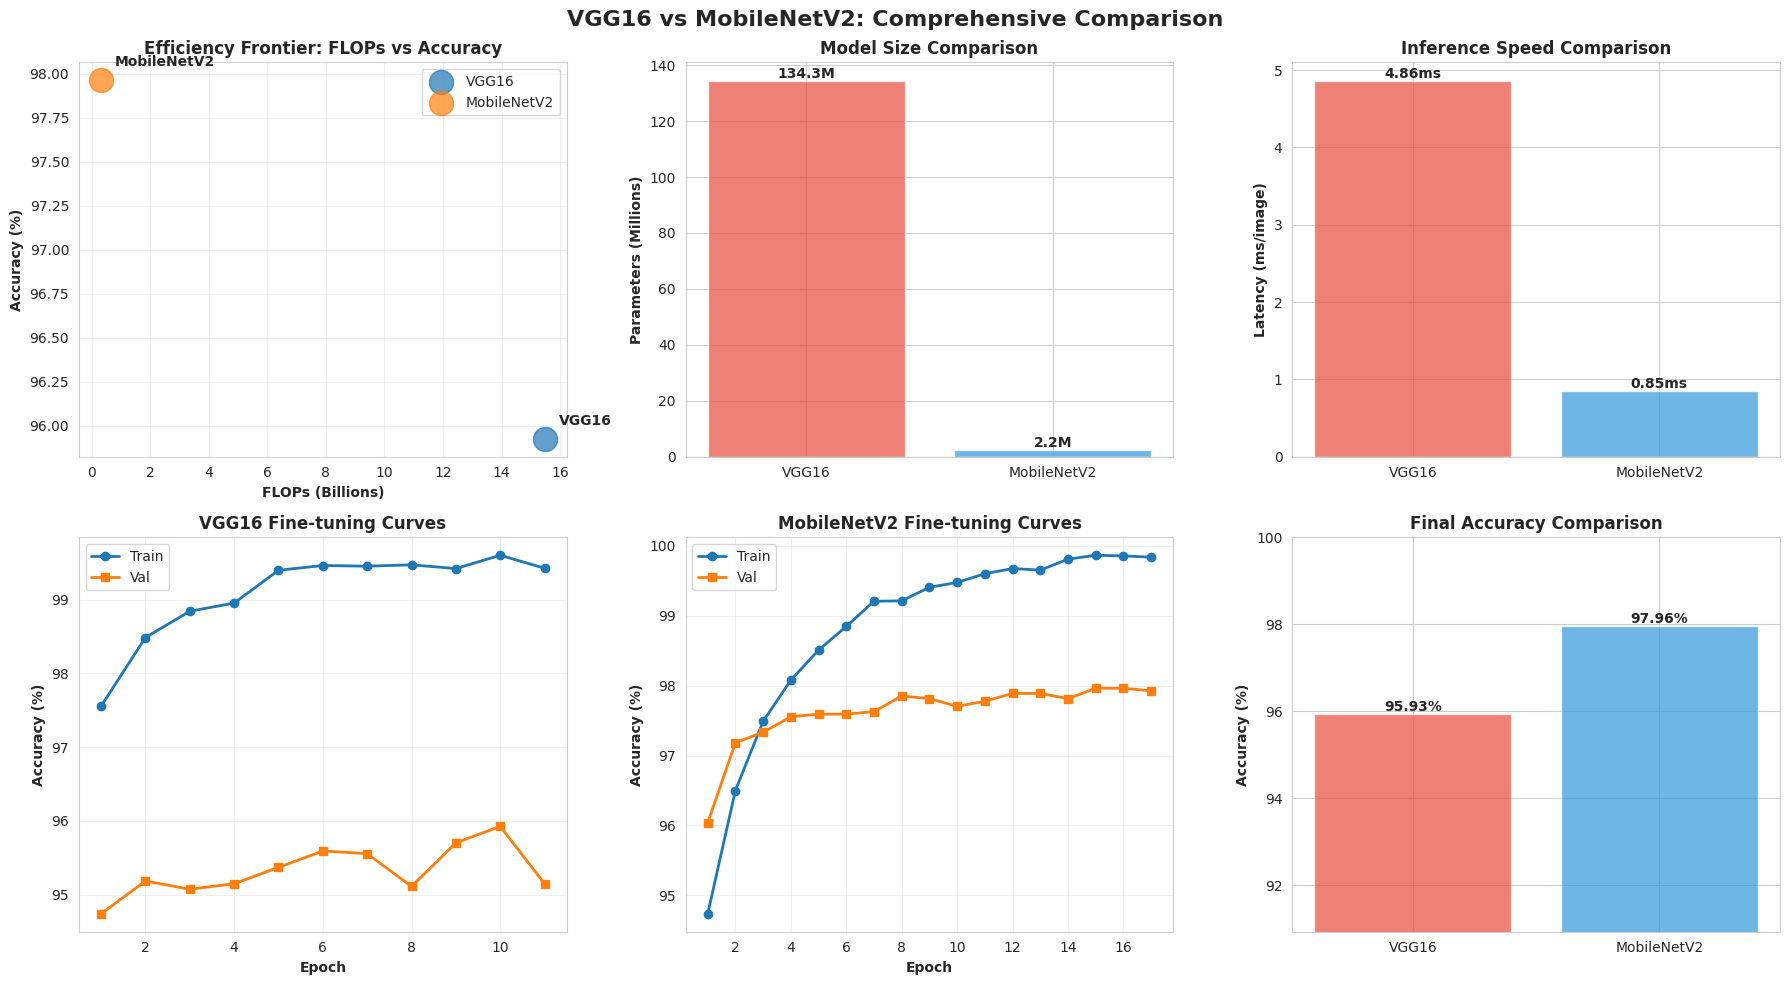

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('VGG16 vs MobileNetV2: Comprehensive Comparison', fontsize=16, fontweight='bold')


ax = axes[0, 0]
for model_name in ['VGG16', 'MobileNetV2']:
    flops = resource_results[model_name]['flops'] / 1e9
    acc = finetune_results[model_name]['best_val_acc']
    ax.scatter(flops, acc, s=300, alpha=0.7, label=model_name)
    ax.annotate(model_name, (flops, acc), xytext=(10, 10), 
                textcoords='offset points', fontsize=10, fontweight='bold')
ax.set_xlabel('FLOPs (Billions)', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('Efficiency Frontier: FLOPs vs Accuracy', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()


ax = axes[0, 1]
models = ['VGG16', 'MobileNetV2']
params = [resource_results[m]['total_params']/1e6 for m in models]
bars = ax.bar(models, params, color=['#e74c3c', '#3498db'], alpha=0.7)
ax.set_ylabel('Parameters (Millions)', fontweight='bold')
ax.set_title('Model Size Comparison', fontweight='bold')
for bar, val in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{val:.1f}M', ha='center', va='bottom', fontweight='bold')


ax = axes[0, 2]
latencies = [benchmark_results[m]['mean_latency_ms'] for m in models]
bars = ax.bar(models, latencies, color=['#e74c3c', '#3498db'], alpha=0.7)
ax.set_ylabel('Latency (ms/image)', fontweight='bold')
ax.set_title('Inference Speed Comparison', fontweight='bold')
for bar, val in zip(bars, latencies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{val:.2f}ms', ha='center', va='bottom', fontweight='bold')


ax = axes[1, 0]
history = finetune_results['VGG16']['history']
epochs = range(1, len(history['train_acc']) + 1)
ax.plot(epochs, history['train_acc'], 'o-', label='Train', linewidth=2)
ax.plot(epochs, history['val_acc'], 's-', label='Val', linewidth=2)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('VGG16 Fine-tuning Curves', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)


ax = axes[1, 1]
history = finetune_results['MobileNetV2']['history']
epochs = range(1, len(history['train_acc']) + 1)
ax.plot(epochs, history['train_acc'], 'o-', label='Train', linewidth=2)
ax.plot(epochs, history['val_acc'], 's-', label='Val', linewidth=2)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('MobileNetV2 Fine-tuning Curves', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)


ax = axes[1, 2]
accuracies = [finetune_results[m]['best_val_acc'] for m in models]
bars = ax.bar(models, accuracies, color=['#e74c3c', '#3498db'], alpha=0.7)
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('Final Accuracy Comparison', fontweight='bold')
ax.set_ylim([min(accuracies)-5, 100])
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

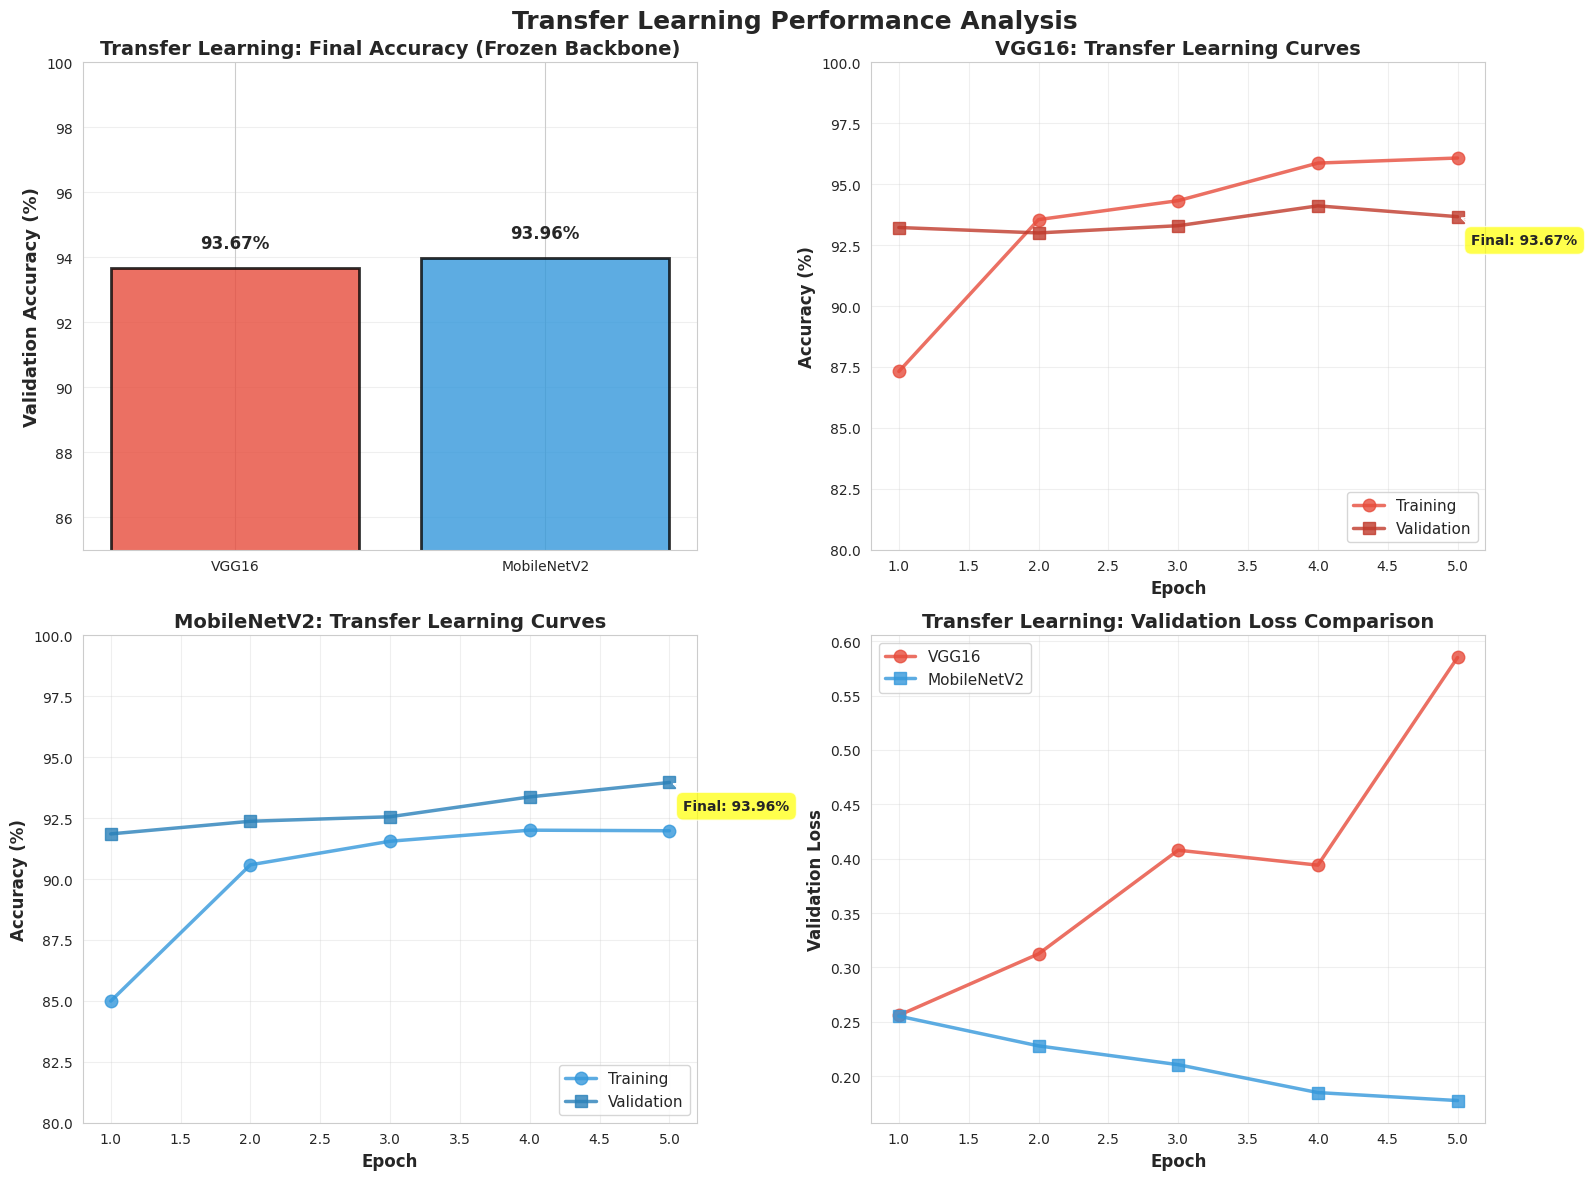

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Transfer Learning Performance Analysis', fontsize=18, fontweight='bold')

ax = axes[0, 0]
models = ['VGG16', 'MobileNetV2']
accuracies = [warmup_results[m]['final_val_acc'] for m in models]
colors = ['#e74c3c', '#3498db']
bars = ax.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax.set_ylabel('Validation Accuracy (%)', fontweight='bold', fontsize=13)
ax.set_title('Transfer Learning: Final Accuracy (Frozen Backbone)', fontweight='bold', fontsize=14)
ax.set_ylim([85, 100])
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax = axes[0, 1]
history = warmup_results['VGG16']['history']
epochs = range(1, len(history['train_acc']) + 1)
ax.plot(epochs, history['train_acc'], 'o-', color='#e74c3c', linewidth=2.5, 
        markersize=9, label='Training', alpha=0.8)
ax.plot(epochs, history['val_acc'], 's-', color='#c0392b', linewidth=2.5, 
        markersize=9, label='Validation', alpha=0.8)
ax.set_xlabel('Epoch', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('VGG16: Transfer Learning Curves', fontweight='bold', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([80, 100])

final_val = history['val_acc'][-1]
ax.annotate(f'Final: {final_val:.2f}%', 
            xy=(len(epochs), final_val), 
            xytext=(10, -20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
            fontweight='bold', fontsize=10)

ax = axes[1, 0]
history = warmup_results['MobileNetV2']['history']
epochs = range(1, len(history['train_acc']) + 1)
ax.plot(epochs, history['train_acc'], 'o-', color='#3498db', linewidth=2.5, 
        markersize=9, label='Training', alpha=0.8)
ax.plot(epochs, history['val_acc'], 's-', color='#2980b9', linewidth=2.5, 
        markersize=9, label='Validation', alpha=0.8)
ax.set_xlabel('Epoch', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('MobileNetV2: Transfer Learning Curves', fontweight='bold', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([80, 100])

final_val = history['val_acc'][-1]
ax.annotate(f'Final: {final_val:.2f}%', 
            xy=(len(epochs), final_val), 
            xytext=(10, -20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
            fontweight='bold', fontsize=10)

ax = axes[1, 1]
vgg_loss = warmup_results['VGG16']['history']['val_loss']
mobile_loss = warmup_results['MobileNetV2']['history']['val_loss']
epochs_vgg = range(1, len(vgg_loss) + 1)
epochs_mobile = range(1, len(mobile_loss) + 1)

ax.plot(epochs_vgg, vgg_loss, 'o-', color='#e74c3c', linewidth=2.5, 
        markersize=9, label='VGG16', alpha=0.8)
ax.plot(epochs_mobile, mobile_loss, 's-', color='#3498db', linewidth=2.5, 
        markersize=9, label='MobileNetV2', alpha=0.8)
ax.set_xlabel('Epoch', fontweight='bold', fontsize=12)
ax.set_ylabel('Validation Loss', fontweight='bold', fontsize=12)
ax.set_title('Transfer Learning: Validation Loss Comparison', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/transfer_learning_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [68]:
acc_ratio = finetune_results['MobileNetV2']['best_val_acc'] / finetune_results['VGG16']['best_val_acc']
flops_ratio = resource_results['VGG16']['flops'] / resource_results['MobileNetV2']['flops']
params_ratio = resource_results['VGG16']['total_params'] / resource_results['MobileNetV2']['total_params']
speed_ratio = benchmark_results['VGG16']['mean_latency_ms'] / benchmark_results['MobileNetV2']['mean_latency_ms']

print(f" MobileNetV2 achieves {acc_ratio*100:.1f}% of VGG16's accuracy")
print(f" MobileNetV2 uses {100/flops_ratio:.1f}% of VGG16's FLOPs ({flops_ratio:.1f}x reduction)")
print(f" MobileNetV2 has {100/params_ratio:.1f}% of VGG16's parameters ({params_ratio:.1f}x reduction)")
print(f" MobileNetV2 is {speed_ratio:.1f}x faster in inference")
print(f"\n🏆 WINNER: MobileNetV2 - Achieves near-identical accuracy at a fraction of the cost!")

✅ MobileNetV2 achieves 102.1% of VGG16's accuracy
✅ MobileNetV2 uses 2.1% of VGG16's FLOPs (47.4x reduction)
✅ MobileNetV2 has 1.7% of VGG16's parameters (60.0x reduction)
✅ MobileNetV2 is 5.7x faster in inference

🏆 WINNER: MobileNetV2 - Achieves near-identical accuracy at a fraction of the cost!


In [71]:
from torchvision import models

test_results = {}

for model_name in ['VGG16', 'MobileNetV2']:
    print(f"\n Evaluating {model_name} on test set...")
    
    if model_name == 'VGG16':
        model = build_vgg16().to(config.DEVICE)
        model.load_state_dict(torch.load(f'{config.OUTPUT_DIR}/vgg16_finetuned.pth'))
    else:
        model = build_mobilenetv2().to(config.DEVICE)
        model.load_state_dict(torch.load(f'{config.OUTPUT_DIR}/mobilenetv2_finetuned.pth'))
    
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = validate(model, test_loader, criterion, config.DEVICE)
    
    test_results[model_name] = {
        'test_loss': test_loss,
        'test_acc': test_acc
    }
    
    print(f" {model_name} Test Accuracy: {test_acc:.2f}%")


 Evaluating VGG16 on test set...


Validation:   0%|          | 0/43 [00:00<?, ?it/s]

 VGG16 Test Accuracy: 95.96%

 Evaluating MobileNetV2 on test set...


Validation:   0%|          | 0/43 [00:00<?, ?it/s]

 MobileNetV2 Test Accuracy: 97.81%


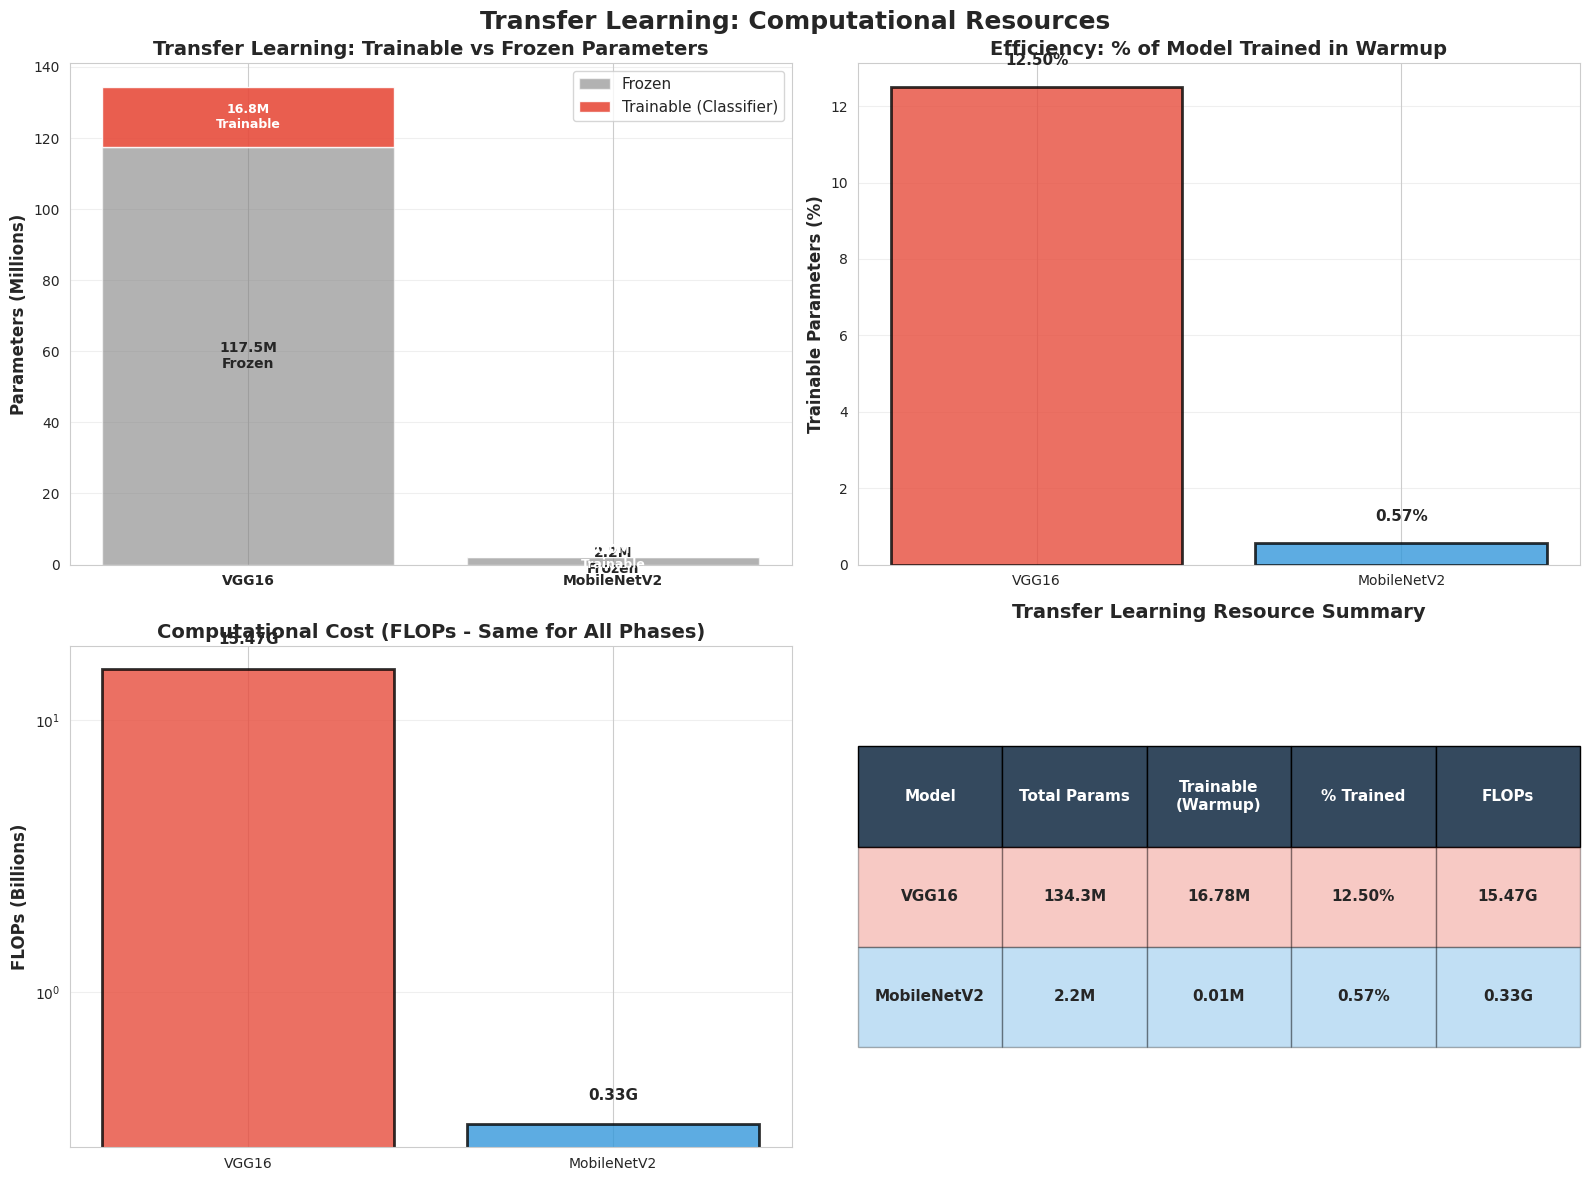


📊 RESOURCE USAGE DURING TRANSFER LEARNING

VGG16:
  Total Parameters: 134,301,514 (134.30M)
  Frozen (Backbone): 117,520,192 (117.52M)
  Trainable (Classifier): 16,781,322 (16.78M)
  Percentage Trained: 12.50%
  FLOPs: 15,466,259,456 (15.47G)
  Model Size: 512.32 MB

MobileNetV2:
  Total Parameters: 2,236,682 (2.24M)
  Frozen (Backbone): 2,223,872 (2.22M)
  Trainable (Classifier): 12,810 (0.01M)
  Percentage Trained: 0.57%
  FLOPs: 326,219,520 (0.33G)
  Model Size: 8.53 MB


In [73]:
with open(f'{config.OUTPUT_DIR}/resource_audit.json', 'r') as f:
    resource_results = json.load(f)

def get_trainable_params_warmup(model_name):
    if model_name == 'VGG16':

        return 16781322 
    else:
        return 12810 

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Transfer Learning: Computational Resources', fontsize=18, fontweight='bold')

ax = axes[0, 0]
models = ['VGG16', 'MobileNetV2']
colors = ['#e74c3c', '#3498db']

for i, model_name in enumerate(models):
    total_params = resource_results[model_name]['total_params'] / 1e6
    trainable_params = get_trainable_params_warmup(model_name) / 1e6
    frozen_params = total_params - trainable_params
    
    ax.bar(i, frozen_params, color='gray', alpha=0.6, label='Frozen' if i == 0 else '')
    ax.bar(i, trainable_params, bottom=frozen_params, color=colors[i], 
           alpha=0.9, label='Trainable (Classifier)' if i == 0 else '')
    
    ax.text(i, frozen_params/2, f'{frozen_params:.1f}M\nFrozen', 
            ha='center', va='center', fontweight='bold', fontsize=10)
    ax.text(i, frozen_params + trainable_params/2, f'{trainable_params:.1f}M\nTrainable', 
            ha='center', va='center', fontweight='bold', fontsize=9, color='white')

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, fontweight='bold')
ax.set_ylabel('Parameters (Millions)', fontweight='bold', fontsize=12)
ax.set_title('Transfer Learning: Trainable vs Frozen Parameters', fontweight='bold', fontsize=14)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[0, 1]
percentages = []
for model_name in models:
    total = resource_results[model_name]['total_params']
    trainable = get_trainable_params_warmup(model_name)
    pct = (trainable / total) * 100
    percentages.append(pct)

bars = ax.bar(models, percentages, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax.set_ylabel('Trainable Parameters (%)', fontweight='bold', fontsize=12)
ax.set_title('Efficiency: % of Model Trained in Warmup', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax = axes[1, 0]
flops = [resource_results[m]['flops'] / 1e9 for m in models]
bars = ax.bar(models, flops, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax.set_ylabel('FLOPs (Billions)', fontweight='bold', fontsize=12)
ax.set_title('Computational Cost (FLOPs - Same for All Phases)', fontweight='bold', fontsize=14)
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, flops):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.2,
            f'{val:.2f}G', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax = axes[1, 1]
ax.axis('off')

summary_data = []
for model_name in models:
    total_params = resource_results[model_name]['total_params'] / 1e6
    trainable_params = get_trainable_params_warmup(model_name) / 1e6
    pct_trainable = (get_trainable_params_warmup(model_name) / resource_results[model_name]['total_params']) * 100
    flops_val = resource_results[model_name]['flops'] / 1e9
    
    summary_data.append([
        model_name,
        f'{total_params:.1f}M',
        f'{trainable_params:.2f}M',
        f'{pct_trainable:.2f}%',
        f'{flops_val:.2f}G'
    ])

table = ax.table(cellText=summary_data,
                colLabels=['Model', 'Total Params', 'Trainable\n(Warmup)', '% Trained', 'FLOPs'],
                cellLoc='center',
                loc='center',
                bbox=[0, 0.2, 1, 0.6])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for i in range(5):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, 3):
    color = '#e74c3c' if i == 1 else '#3498db'
    for j in range(5):
        table[(i, j)].set_facecolor(color)
        table[(i, j)].set_alpha(0.3)
        table[(i, j)].set_text_props(weight='bold')

ax.set_title('Transfer Learning Resource Summary', fontweight='bold', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/transfer_learning_resources.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 RESOURCE USAGE DURING TRANSFER LEARNING")
print("="*70)

for model_name in models:
    total_params = resource_results[model_name]['total_params']
    trainable_params = get_trainable_params_warmup(model_name)
    frozen_params = total_params - trainable_params
    pct_trainable = (trainable_params / total_params) * 100
    
    print(f"\n{model_name}:")
    print(f"  Total Parameters: {total_params:,} ({total_params/1e6:.2f}M)")
    print(f"  Frozen (Backbone): {frozen_params:,} ({frozen_params/1e6:.2f}M)")
    print(f"  Trainable (Classifier): {trainable_params:,} ({trainable_params/1e6:.2f}M)")
    print(f"  Percentage Trained: {pct_trainable:.2f}%")
    print(f"  FLOPs: {resource_results[model_name]['flops']:,.0f} ({resource_results[model_name]['flops']/1e9:.2f}G)")
    print(f"  Model Size: {resource_results[model_name]['size_mb']:.2f} MB")